In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print(data.target_names)

print("\nFirst 5 rows:")
print(X.head())


Dataset Shape: (569, 30)

Target Classes:
['malignant' 'benign']

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean frac


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

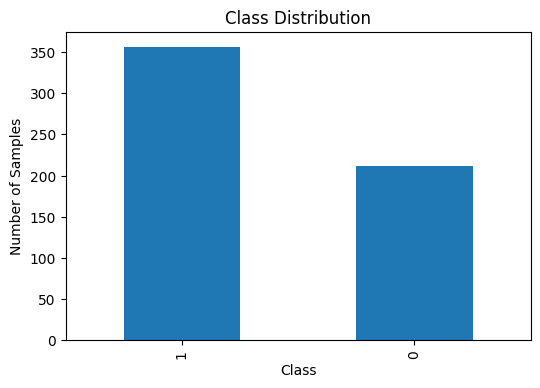

In [ ]:
print("\nDataset Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nClass Distribution:")
print(y.value_counts())

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 455
Testing samples: 114


In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

bagging_params = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}

bagging_grid = GridSearchCV(
    bagging,
    bagging_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)

best_bagging = bagging_grid.best_estimator_

print("\n================ BAGGING ================")
print("Best Parameters:", bagging_grid.best_params_)
print("Best CV Accuracy:", bagging_grid.best_score_)


================ BAGGING ================
Best Parameters: {'max_features': 0.5, 'max_samples': 0.8, 'n_estimators': 100}
Best CV Accuracy: 0.9604395604395606


In [ ]:
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    random_state=42
)

ada_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    adaboost,
    ada_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

best_adaboost = ada_grid.best_estimator_

print("\n================ ADABOOST ================")
print("Best Parameters:", ada_grid.best_params_)
print("Best CV Accuracy:", ada_grid.best_score_)


================ ADABOOST ================
Best Parameters: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV Accuracy: 0.9736263736263737


In [ ]:
gradient = GradientBoostingClassifier(
    random_state=42
)

gradient_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [1, 2, 3]
}

gradient_grid = GridSearchCV(
    gradient,
    gradient_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gradient_grid.fit(X_train, y_train)

best_gradient = gradient_grid.best_estimator_

print("\n================ GRADIENT BOOSTING ================")
print("Best Parameters:", gradient_grid.best_params_)
print("Best CV Accuracy:", gradient_grid.best_score_)


================ GRADIENT BOOSTING ================
Best Parameters: {'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 100}
Best CV Accuracy: 0.9802197802197803


In [ ]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

naive_bayes = GaussianNB()

decision_tree = DecisionTreeClassifier(
    random_state=42
)

base_models = [
    ("svm", svm),
    ("nb", naive_bayes),
    ("dt", decision_tree)
]

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking.fit(X_train, y_train)

print("\n================ STACKING ================")
print("Base Models: SVM, Naive Bayes, Decision Tree")
print("Meta Learner: Logistic Regression")


================ STACKING ================
Base Models: SVM, Naive Bayes, Decision Tree
Meta Learner: Logistic Regression


In [ ]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n-----------------------------------")
    print(model_name)
    print("-----------------------------------")

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }


In [ ]:
results = []

results.append(
    evaluate_model(
        best_bagging,
        X_test,
        y_test,
        "Bagging"
    )
)

results.append(
    evaluate_model(
        best_adaboost,
        X_test,
        y_test,
        "AdaBoost"
    )
)

results.append(
    evaluate_model(
        best_gradient,
        X_test,
        y_test,
        "Gradient Boosting"
    )
)

results.append(
    evaluate_model(
        stacking,
        X_test,
        y_test,
        "Stacking"
    )
)


-----------------------------------
Bagging
-----------------------------------
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1 Score : 0.9583

Confusion Matrix:
[[39  3]
 [ 3 69]]

-----------------------------------
AdaBoost
-----------------------------------
Accuracy : 0.9561
Precision: 0.9467
Recall   : 0.9861
F1 Score : 0.966

Confusion Matrix:
[[38  4]
 [ 1 71]]

-----------------------------------
Gradient Boosting
-----------------------------------
Accuracy : 0.9649
Precision: 0.9595
Recall   : 0.9861
F1 Score : 0.9726

Confusion Matrix:
[[39  3]
 [ 1 71]]

-----------------------------------
Stacking
-----------------------------------
Accuracy : 0.9737
Precision: 0.9726
Recall   : 0.9861
F1 Score : 0.9793

Confusion Matrix:
[[40  2]
 [ 1 71]]


In [ ]:
results_df = pd.DataFrame(results)

print("\n================ PERFORMANCE COMPARISON ================")
print(results_df)


================ PERFORMANCE COMPARISON ================
               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.947368   0.958333  0.958333  0.958333
1           AdaBoost  0.956140   0.946667  0.986111  0.965986
2  Gradient Boosting  0.964912   0.959459  0.986111  0.972603
3           Stacking  0.973684   0.972603  0.986111  0.979310


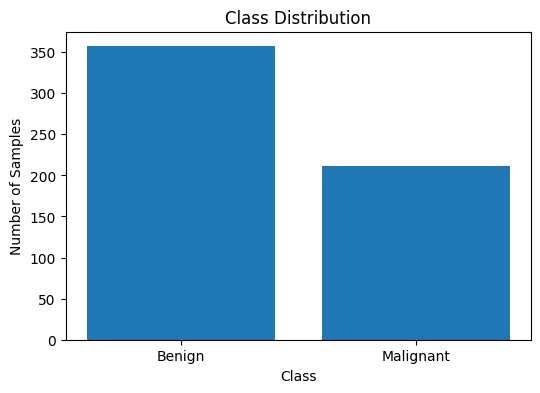

In [ ]:
class_counts = pd.Series(
    y
).map({
    0: "Malignant",
    1: "Benign"
}).value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

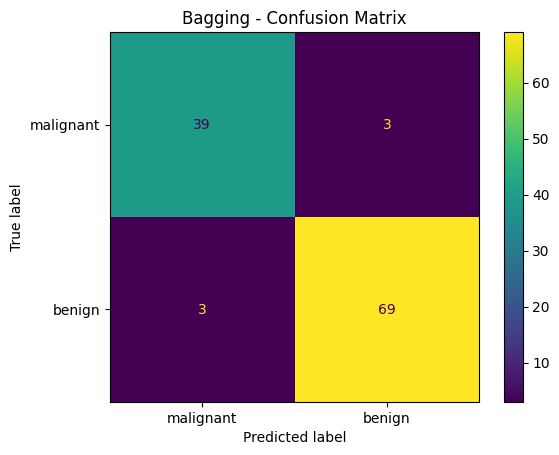

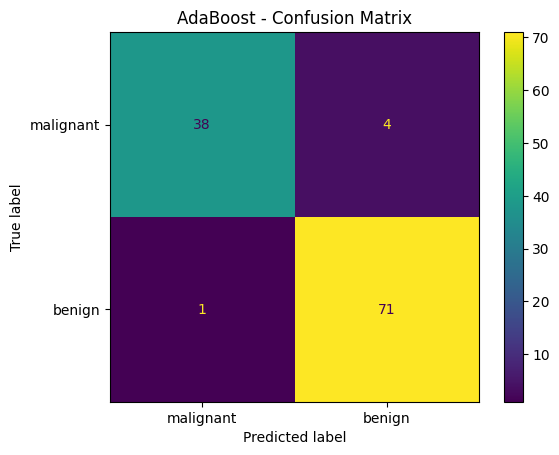

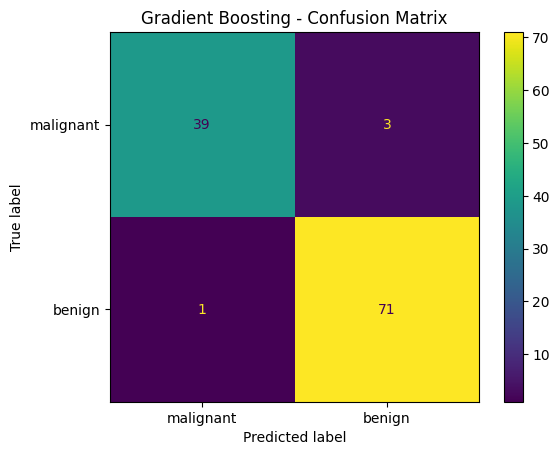

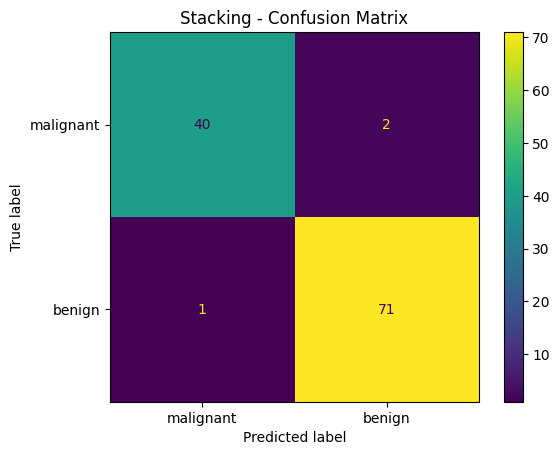

In [ ]:
models = {
    "Bagging": best_bagging,
    "AdaBoost": best_adaboost,
    "Gradient Boosting": best_gradient,
    "Stacking": stacking
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=data.target_names
    )

    disp.plot()
    plt.title(name + " - Confusion Matrix")
    plt.show()


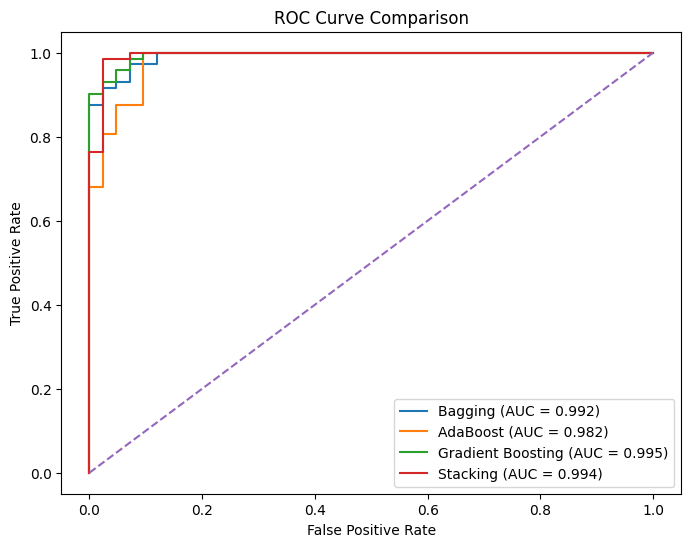

In [ ]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]

    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

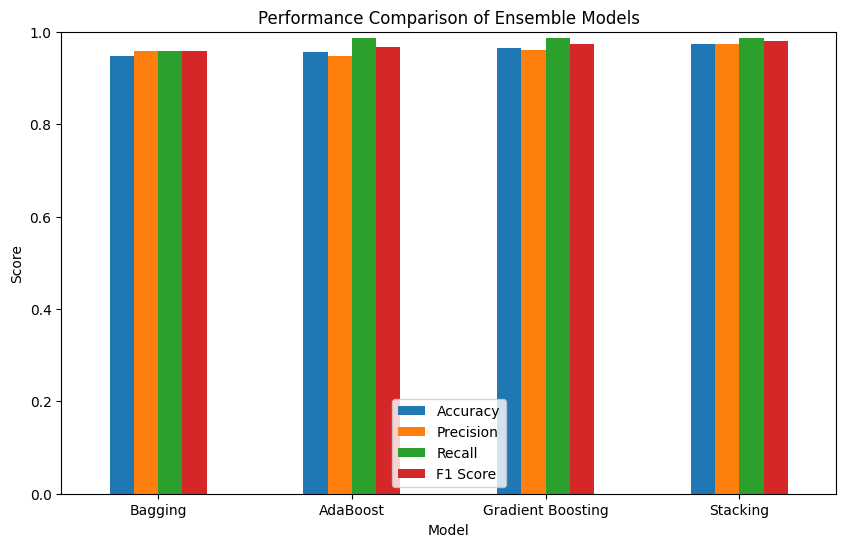

In [ ]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Ensemble Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("\n================ BEST MODEL ================")
print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("F1 Score:", round(best_model["F1 Score"], 4))


================ BEST MODEL ================
Best Model: Stacking
Accuracy: 0.9737
Precision: 0.9726
Recall: 0.9861
F1 Score: 0.9793
